In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/Mrk-553_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/Mrk-553_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 964)   float32   


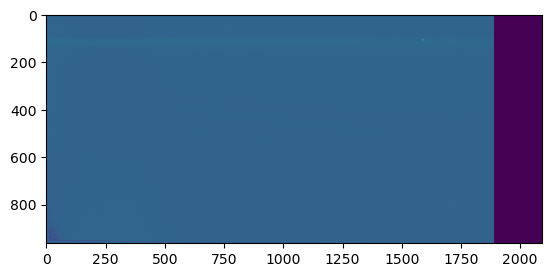

In [3]:
plt.imshow(image)

In [4]:
image_cut = image[70:170, 0:1800]

Text(0.5, 0, 'wavelenght')

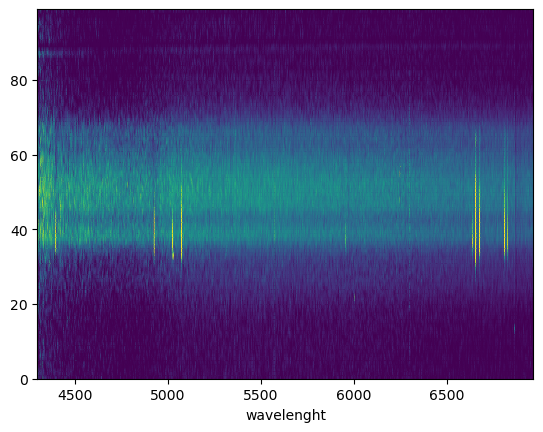

In [5]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

We know that redshift and wavelenghts are related in this way:
$\lambda_{obs} = \lambda_{em}*(1+z)$ \
So if we want:
- $\lambda_{obs}(H\alpha)$ = 6563 * (1+0.01505) = 6662 AA
- $\lambda_{obs}(H\beta)$ = 4861 * (1+0.01505) = 4934 AA
- $\lambda_{obs}([NII])$ = 6548 * (1+0.01505) = 6647 AA
- $\lambda_{obs}([SII])$ = 6717 * (1+0.01505) = 6818 AA
- $\lambda_{obs}([OIII])$ = 4959 * (1+0.01505) = 5034 AA


## Continuum 6500 AA

Text(0.5, 1.0, 'Continuum 6500 A')

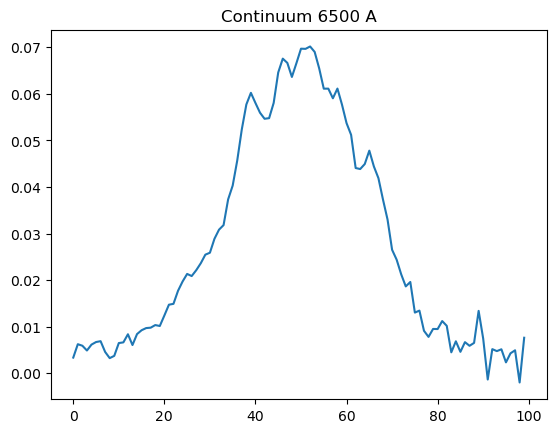

In [6]:
mask = (wavelenghts > 6480)*(wavelenghts < 6520)
image_6500 = image_cut[:, mask] #cut su 6500 A
radial_profile = np.mean(image_6500, axis = 1)
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile)
plt.title('Continuum 6500 A')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

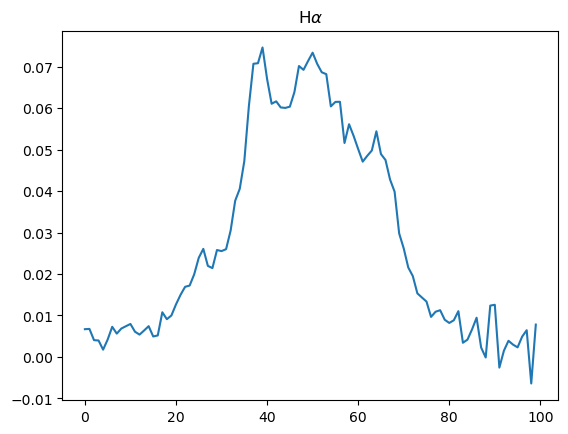

In [7]:
mask_HA = (wavelenghts > 6657)*(wavelenghts < 6667)
image_HA = image_cut[:, mask_HA] #cut su 6719 A
radial_profile_HA = np.mean(image_HA, axis = 1)
plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')

The fit gives us these parameters: A = 1.09, A2 = 0.50, mu = 36.30, mu2 = 59.57


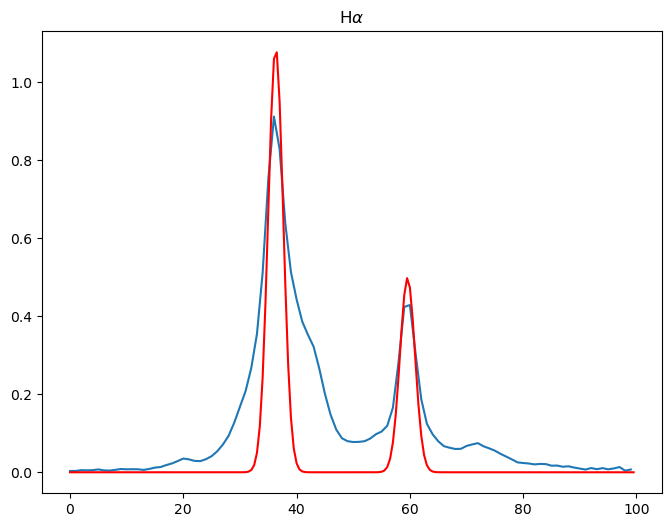

In [26]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2):
    gauss1 = A*np.exp(-(x-mu)**2/(2*sigma**2))
    gauss2 = A2*np.exp(-(x-mu2)**2/(2*sigma**2))
    return gauss1+gauss2
    
params, covariance = curve_fit(model, x_axes, radial_profile_HA, p0=[0.8, 0.4, 40, 60])
A, A2, mu, mu2 = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f' % (A, A2, mu, mu2))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5)

plt.show()

The fit gives us these parameters: A = 0.95, A2 = 0.36, mu = 36.30, mu2 = 59.59, As = 0.10, r_eff = 53.19, n = 0.10


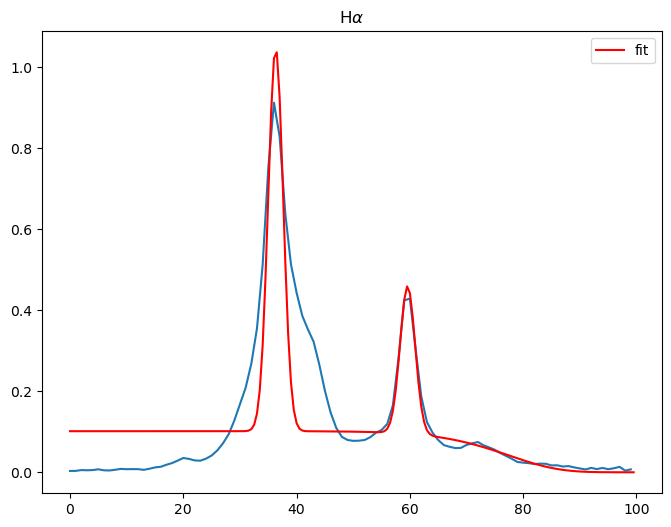

In [32]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_HA, p0=[0.8, 0.4, 40, 60, 1, 50, 1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()

plt.show()

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

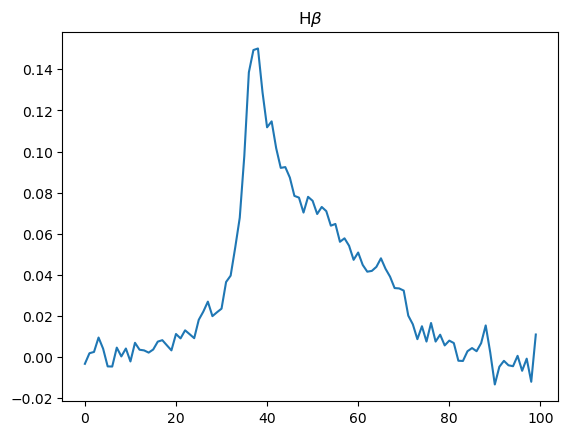

In [18]:
mask_HB = (wavelenghts > 4924)*(wavelenghts < 4944)
image_HB = image_cut[:, mask_HB] #cut su 4977 A
radial_profile_HB = np.mean(image_HB, axis = 1)
plt.plot(x_axes, radial_profile_HB)
plt.title(r'H$\beta$')

The fit gives us these parameters: A = 0.26, A2 = 0.18, mu = 36.15, mu2 = 59.36, As = 0.04, r_eff = 56.28, n = 0.07


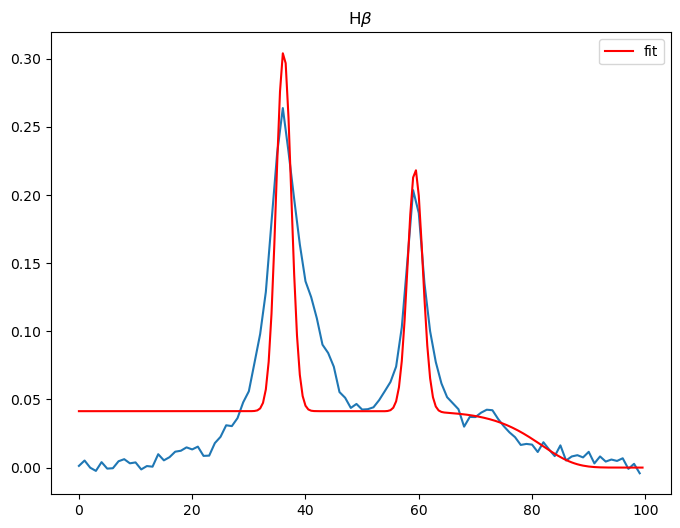

In [40]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_HB, p0=[0.25, 0.2, 40, 60, 0.1, 50, 0.1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HB)
plt.title(r'H$\beta$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [NII]

Text(0.5, 1.0, '[NII]')

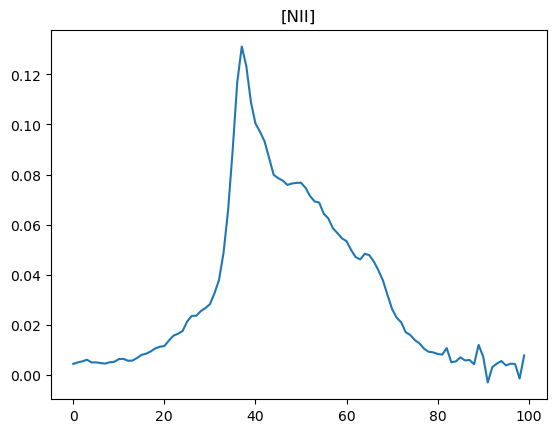

In [19]:
mask_NII = (wavelenghts > 6637)*(wavelenghts < 6757)
image_NII = image_cut[:, mask_NII] #cut su 6704 A
radial_profile_NII = np.mean(image_NII, axis = 1)
plt.plot(x_axes, radial_profile_NII)
plt.title(r'[NII]')

The fit gives us these parameters: A = 0.10, A2 = 0.21, mu = 36.69, mu2 = 59.75, As = 0.03, r_eff = 59.11, n = 0.06


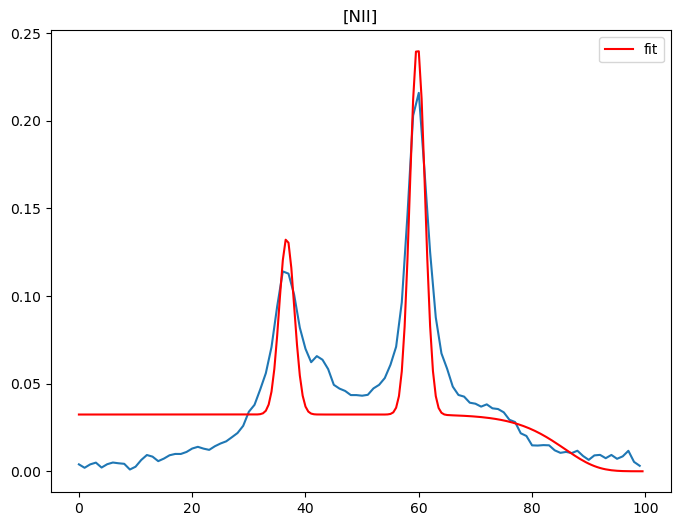

In [39]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_NII, p0=[0.15, 0.2, 40, 60, 0.05, 50, 0.05])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_NII)
plt.title(r'[NII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [SII]

Text(0.5, 1.0, '[SII]')

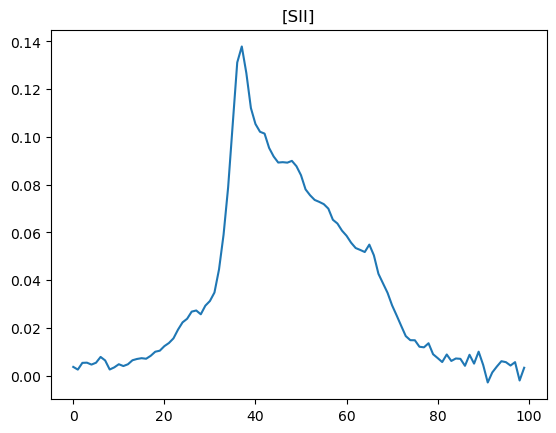

In [20]:
mask_SII = (wavelenghts > 6808)*(wavelenghts < 6828)
image_SII = image_cut[:, mask_SII] #cut su 6877 A
radial_profile_SII = np.mean(image_SII, axis = 1)
plt.plot(x_axes, radial_profile_SII)
plt.title(r'[SII]')

The fit gives us these parameters: A = 0.10, A2 = 0.17, mu = 36.76, mu2 = 59.75, As = 0.03, r_eff = 58.34, n = 0.06


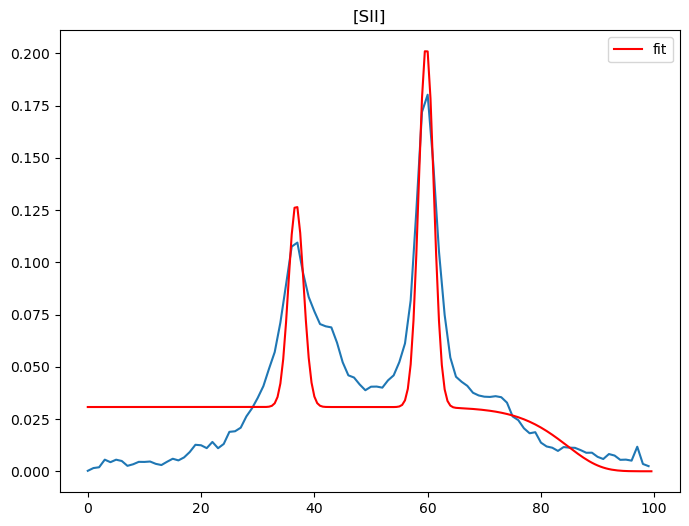

In [41]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_SII, p0=[0.125, 0.175, 40, 60, 0.05, 50, 0.05])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_SII)
plt.title(r'[SII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [OIII]

Text(0.5, 1.0, '[OIII]')

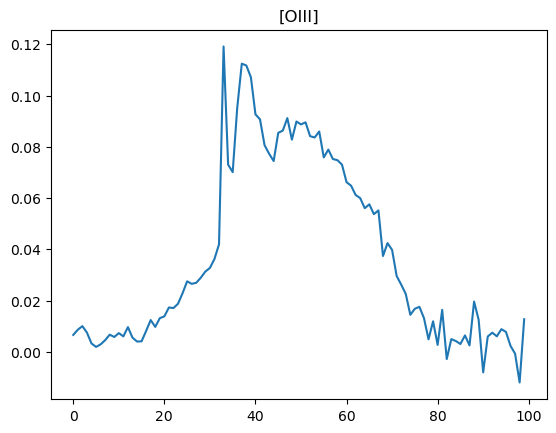

In [21]:
mask_OIII = (wavelenghts > 5024)*(wavelenghts < 5044)
image_OIII = image_cut[:, mask_OIII] #cut su 5077 A
radial_profile_OIII = np.mean(image_OIII, axis = 1)
plt.plot(x_axes, radial_profile_OIII)
plt.title(r'[OIII]')

The fit gives us these parameters: A = 0.13, A2 = 0.19, mu = 36.30, mu2 = 59.57, As = 0.04, r_eff = 59.43, n = 0.07


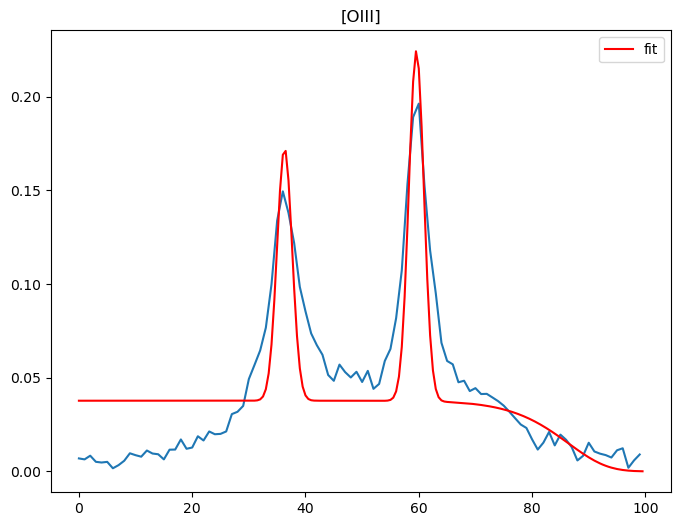

In [43]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_OIII, p0=[0.15, 0.2, 40, 60, 0.1, 50, 0.1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_OIII)
plt.title(r'[OIII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()